<a href="https://colab.research.google.com/github/kasev/mops/blob/master/scripts/colab_exploring-matrices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import pickle
import urllib
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:

from google.colab import files
# defining function for saving+downloading the latest figure

def download_figure(fig=None, filename=None):
  if (filename==None) | (".png" not in str(filename)):
    filename = "figure.png"
  if fig==None:
    plt.savefig(filename)
  else:
    fig.savefig(filename)
  files.download(filename)

In [3]:
# load vocabularies
try:
    bidecades_vocabs_counts_df = pickle.load(open("../data/bidecades_vocabs_counts_df.pickle", "rb"))
except:
    bidecades_vocabs_counts_df = pickle.load(urllib.request.urlopen("https://github.com/kasev/mops/raw/master/data/bidecades_vocabs_counts_df.pickle"))

In [4]:
# locally
try:
    cooc_dict = pickle.load(open("../data/cooc_dict.pickle", "rb"))
except:
    urllib.request.urlretrieve("https://github.com/kasev/mops/raw/master/data/cooc_dict.pickle", "temp.pickle")
    with open("temp.pickle", "rb") as f:
        cooc_dict = pickle.load(f)

In [5]:
# transform the matrcices into dataframes (much more memory consuming...)
for bidecade, cooc in cooc_dict.items():
    try:
        cooc_df = pd.DataFrame(cooc.todense())
        cooc_norm_df = cooc_df / cooc_df.max()
        cooc_norm_df.columns = bidecades_vocabs_counts_df.index
        cooc_norm_df.index = bidecades_vocabs_counts_df.index
        cooc_dict[bidecade] = cooc_norm_df
    except:
        pass

In [8]:
cooc_dict["1900-1919"]

,man,new,god,jesus,paul,make,church,life,see,say,...,monotheism,neutral,revisit,nonviolence,endorse,fundamentalism,overarch,glossary,markan,indepth
man,1.000000,0.002031,0.032996,0.011614,0.004337,0.017993,0.001939,0.014475,0.015900,0.024699,...,0.000000,0.0,NaN,NaN,0.0,NaN,NaN,0.0,0.0,NaN
new,0.002967,1.000000,0.003948,0.008184,0.002613,0.004192,0.010131,0.022177,0.004662,0.003150,...,0.000000,0.0,NaN,NaN,0.0,NaN,NaN,0.0,0.0,NaN
god,0.034379,0.002815,1.000000,0.010781,0.002829,0.022548,0.004841,0.006175,0.018558,0.030951,...,0.000000,0.0,NaN,NaN,0.0,NaN,NaN,0.0,0.0,NaN
jesus,0.012812,0.006179,0.011415,1.000000,0.020461,0.014088,0.002257,0.056299,0.014299,0.052359,...,0.000000,0.0,NaN,NaN,0.0,NaN,NaN,0.0,0.0,NaN
paul,0.003994,0.001647,0.002500,0.017078,1.000000,0.012344,0.005880,0.014336,0.009256,0.036125,...,0.052595,0.0,NaN,NaN,0.0,NaN,NaN,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fundamentalism,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,NaN,NaN,0.0,NaN,NaN,0.0,0.0,NaN
overarch,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,NaN,NaN,0.0,NaN,NaN,0.0,0.0,NaN
glossary,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,NaN,NaN,0.0,NaN,NaN,1.0,0.0,NaN
markan,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,NaN,NaN,0.0,NaN,NaN,0.0,1.0,NaN


In [9]:
cooc_dict["1900-1919"]["paul"].sort_values(ascending=False).head(20)

,paul
paul,1.000000
apostle,0.109388
epistle,0.090078
letter,0.047584
saint,0.027381
jesus,0.020461
write,0.017618
use,0.015502
say,0.014395
life,0.013396


In [10]:
cooc_dict["1980-1999"]["paul"].sort_values(ascending=False).head(20)

,paul
paul,1.000000
letter,0.066873
apostle,0.047831
use,0.029334
epistle,0.019538
say,0.014276
theology,0.014109
write,0.012220
argument,0.010826
john,0.010728


In [11]:
def return_tfidf_position(key1, key2, bidecade):
    position = cooc_dict[bidecade][key1].sort_values(ascending=False).index.get_loc(key2)
    return position

In [12]:
# define bidecades:
bidecades_list = ['1900-1919', '1920-1939', '1940-1959', '1960-1979', '1980-1999',
 '2000-2019']

In [16]:
return_tfidf_position("paul", "theology", "2000-2019")

4

In [14]:
# development...
key1 = "paul"
key2 = "theology"
positions = []
for bidecade in bidecades_list:
    positions.append(return_tfidf_position(key1, key2, bidecade))

In [15]:
positions

[28, 14, 30, 13, 6, 4]

In [17]:
def position_by_bidecade(key1, key2):
    positions = []
    for bidecade in bidecades_list:
        positions.append(return_tfidf_position(key1, key2, bidecade))
    return positions

# Explorations...

In [18]:
position_by_bidecade("paul", "judaism")

[353, 322, 237, 231, 105, 31]

In [ ]:
position_by_bidecade("paul", "apostle")


[1, 1, 1, 2, 2, 2]

In [19]:
position_by_bidecade("paul", "apostle")

[1, 1, 1, 2, 2, 2]

In [27]:

def plot_postion_by_bidecade(tuples, figsize=(6,4)):
  all_positions = []
  fig, ax = plt.subplots(tight_layout=True, figsize=figsize, dpi=150)
  #fig.patch.set_facecolor("black")
  #ax.set_facecolor("black")
  colors = sns.color_palette(None, len(tuples))
  for terms, color in zip(tuples, colors):
    positions = position_by_bidecade(terms[0], terms[1])
    all_positions.extend(positions)
    ax.plot(positions, linewidth=2, color=color, label=terms[0]+"~"+terms[1])
  ax.set_title(", ".join([terms[0]+"~"+terms[1] for terms in tuples]), color="white")
  ax.set_xticks(range(6))
  #ax.set_xticklabels(bidecades_list, color="black", rotation=90)
  ax.set_xticklabels(bidecades_list, rotation=90)
  ax.set_yticks(ax.get_yticks())  # This ensures a fixed set of y-tick positions
  if np.max(positions) < 5:
    ax.set_yticklabels([str(np.round(el, 1)) for el in ax.get_yticks()], color="black")
  else:
    ax.set_yticklabels([str(int(el)) for el in ax.get_yticks()], color="black")
  ax.invert_yaxis()
  ax.set_xlabel("bidecade", color="black")
  ax.set_ylabel("rank", color="black")
  # ax.spines['bottom'].set_color('white')
  #ax.spines['top'].set_color('white')
  #ax.spines['right'].set_color('white')
  #ax.spines['left'].set_color('white')
  ax.legend() # facecolor="black", labelcolor="white")
  min_y = max(all_positions)
  ax.set_ylim(min_y, 0)
  return fig

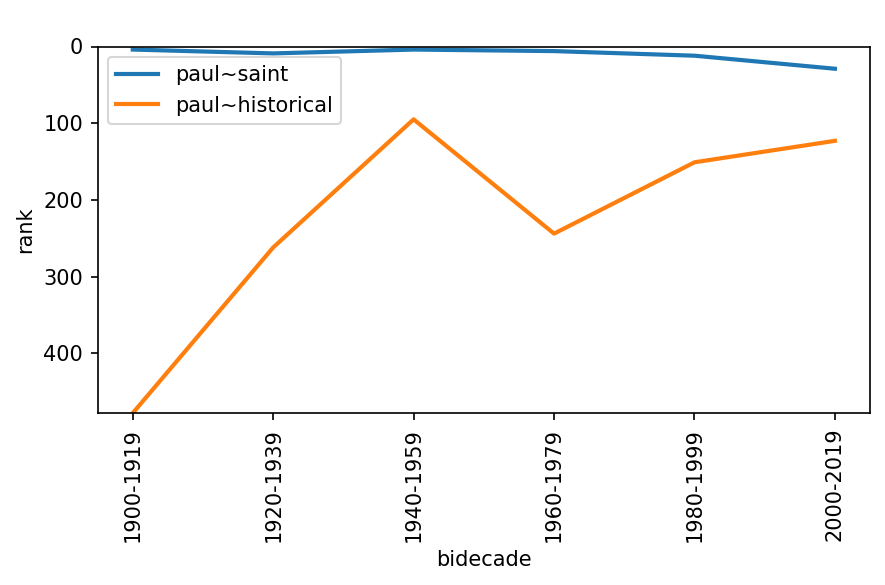

In [28]:
fig = plot_postion_by_bidecade([("paul", "saint"), ("paul", "historical")], figsize=(6,4))

In [ ]:
try:
    fig.savefig("../figures/paul-saint_vs_historical.png")
except:
    download_figure(fig)

In [ ]:

# download_figure(fig)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Explorations of half-decades from the last 30 years...

I divided the last 30 years into these six halfdecades:
halfdecades_strs = ['1990-1994', '1995-1999', '2000-2004', '2005-2009', '2010-2014', '2015-2019']
These



In [31]:
# locally
try:
    cooc_dict_2000 = pickle.load(open("../data/cooc_dict_2000.pickle", "rb"))
except:
    urllib.request.urlretrieve("https://github.com/kasev/mops/raw/master/data/cooc_dict_2000.pickle", "temp.pickle")
    with open("temp.pickle", "rb") as f:
        cooc_dict_2000 = pickle.load(f)

In [32]:
cooc_dict_2000.keys()

dict_keys(['1990-1994', '1995-1999', '2000-2004', '2005-2009', '2010-2014', '2015-2019'])

In [33]:
halfdecades_strs = ['1990-1994', '1995-1999', '2000-2004', '2005-2009', '2010-2014', '2015-2019']

In [34]:
# transform the matrcices into dataframes (much more memory consuming...)
for halfdecade, cooc in cooc_dict_2000.items():
    try:
        cooc_df = pd.DataFrame(cooc.todense())
        cooc_norm_df = cooc_df / cooc_df.max()
        cooc_norm_df.columns = bidecades_vocabs_counts_df.index
        cooc_norm_df.index = bidecades_vocabs_counts_df.index
        cooc_dict_2000[halfdecade] = cooc_norm_df
    except:
        pass

In [35]:
cooc_dict_2000[halfdecades_strs[0]]

,man,new,god,jesus,paul,make,church,life,see,say,...,monotheism,neutral,revisit,nonviolence,endorse,fundamentalism,overarch,glossary,markan,indepth
man,1.000000,0.006226,0.008440,0.005235,0.001586,0.009398,0.000764,0.003314,0.006987,0.009935,...,0.00000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
new,0.015672,1.000000,0.002797,0.003536,0.004916,0.002282,0.007947,0.016086,0.001499,0.001563,...,0.01052,0.0,0.002636,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
god,0.017105,0.002252,1.000000,0.011899,0.002809,0.015271,0.006621,0.007705,0.013384,0.034290,...,0.00000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
jesus,0.006027,0.001617,0.006759,1.000000,0.007646,0.004148,0.004188,0.014385,0.005160,0.031084,...,0.00000,0.0,0.003732,0.0,0.000000,0.0,0.0,0.0,0.015929,0.0
paul,0.003590,0.004419,0.003137,0.015030,1.000000,0.009025,0.006556,0.011918,0.013986,0.063062,...,0.00000,0.0,0.000000,0.0,0.009161,0.0,0.0,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fundamentalism,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.0,0.000000,0.0,0.000000,1.0,0.0,0.0,0.000000,0.0
overarch,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.0,0.000000,0.0,0.000000,0.0,1.0,0.0,0.000000,0.0
glossary,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.0,0.000000,0.0,0.000000,0.0,0.0,1.0,0.000000,0.0
markan,0.000000,0.000000,0.000000,0.000110,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,1.000000,0.0


In [46]:
cooc_dict_2000["2015-2019"]["paul"].sort_values(ascending=False)

,paul
paul,1.000000
letter,0.058125
use,0.035130
apostle,0.033535
john,0.018457
...,...
payment,0.000000
inquire,0.000000
penalty,0.000000
archbishop,0.000000


In [36]:
def return_tfidf_position_halfdecade(key1, key2, halfdecade):
    position = cooc_dict_2000[halfdecade][key1].sort_values(ascending=False).index.get_loc(key2)
    return position

In [37]:
def position_by_halfdecade(key1, key2):
    positions = []
    for halfdecade in halfdecades_strs:
        positions.append(return_tfidf_position_halfdecade(key1, key2, halfdecade))
    return positions

In [40]:
def plot_postion_by_halfdecade(tuples, figsize=(6,4)):
    fig, ax = plt.subplots(tight_layout=True, figsize=figsize, dpi=150)
    #fig.patch.set_facecolor("black")
    #ax.set_facecolor("black")
    colors = sns.color_palette(None, len(tuples))
    for terms, color in zip(tuples, colors):
        positions = position_by_halfdecade(terms[0], terms[1])
        ax.plot(positions, linewidth=2, color=color, label=terms[0]+"~"+terms[1])
    ax.set_title(", ".join([terms[0]+"~"+terms[1] for terms in tuples])) # , color="white")
    ax.set_xticks(range(6))
    ax.set_xticklabels(halfdecades_strs, rotation=90) # color="white",
    #if np.max(positions) < 5:
    #  ax.set_yticklabels([str(np.round(el, 1)) for el in ax.get_yticks()], color="white")
    #else:
    ax.set_yticks(ax.get_yticks())  # This ensures a fixed set of y-tick positions
    ax.set_yticklabels([str(int(el)) for el in ax.get_yticks()]) # , color="white"
    ax.invert_yaxis()
    ax.set_xlabel("halfdecade") # , color="white")
    ax.set_ylabel("rank") # , color="white")
    #ax.spines['bottom'].set_color('white')
    #ax.spines['top'].set_color('white')
    #ax.spines['right'].set_color('white')
    #ax.spines['left'].set_color('white')
    #ax.legend(facecolor="black", labelcolor="white")
    return fig

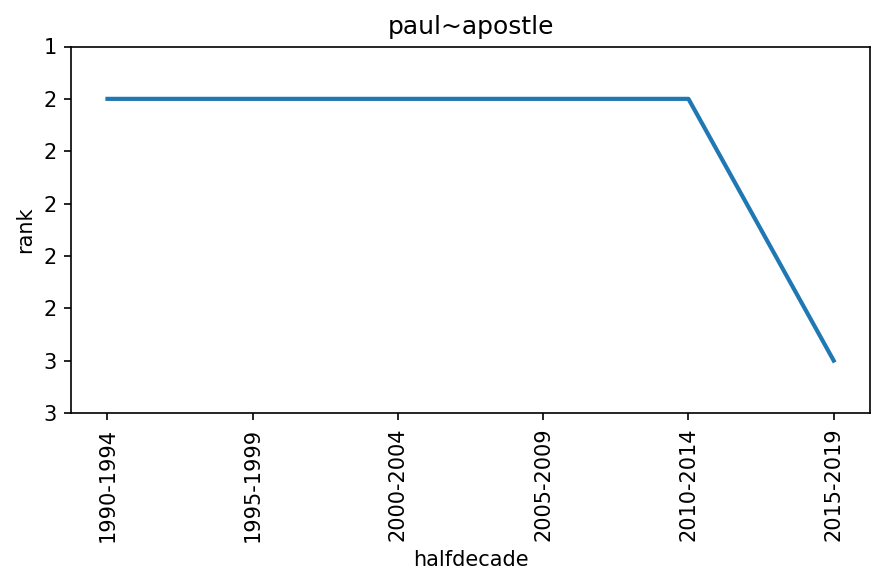

In [41]:
fig = plot_postion_by_halfdecade([("paul", "apostle")])